In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import awkward as ak
import energyflow as ef
import fastjet as fj
import utils
import visualize as vis

In [3]:
import sys
sys.path.append("../utils")
import data_utils as du  # noqa: E402
import jet_clusterer

In [6]:
# Get TTree and pass 190 flags
f = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_5Jul2025_MGPy8FxFxPlusNonStrong_syst_Test_withdd.root"
)
t = f["OmniTree"]
pass190 = ak.to_numpy(t["truth_pass190"].array())

f_pd = uproot.open(
    "/pscratch/sd/k/kgreif/data/TruthPseudodata_Sherpa2211DY_Dibo_EW_PowhegPythiaTop_PosWeights_WithTracks_June2025_shuffled.root"
)
t_pd = f_pd["OmniTree"]
pass190_pd = ak.to_numpy(t_pd["truth_pass190"].array())

f_hv = uproot.open(
    "/pscratch/sd/k/kgreif/zjets_plot_staging/ZjetOmnifold_Mar10_Sherpa2211_LookLike_MgFxFx_Test_V5.root"
)
t_hv = f_hv["OmniTree"]
pass190_hv = ak.to_numpy(t_hv["truth_pass190"].array())

f_data = uproot.open(
    "/pscratch/sd/k/kgreif/data/ZjetOmnifold_Nov11_data_WithTracks_slim_Systematics_shuffled.root"
)
t_data = f_data["OmniTree"]
pass190_data = np.ones(t_data.num_entries)

f_mg = uproot.open(
    "/global/cfs/cdirs/m3246/ZjetOmnifold/data/truth_gen/madgraph/ZjetOmnifold_May19_MGPy8FxFx_All_shuffled.root"
)
t_mg = f_mg["OmniTree"]
pass190_mg = ak.to_numpy(t_mg["truth_pass190"].array())

f_sherpa = uproot.open(
    "/global/cfs/cdirs/m3246/ZjetOmnifold/data/truth_gen/sherpa/ZjetOmnifold_30Jul2025_Sherpa2211Truth_shuffled.root"
)
t_sherpa = f_sherpa["OmniTree"]
pass190_sherpa = ak.to_numpy(t_sherpa["truth_pass190"].array(entry_stop=5000000))

In [5]:
# Set parameters for jet clustering
algorithm = fj.antikt_algorithm
R = 1.0
ptmin = 500.0
ptmax = 550.0
etamax = 1.2

In [ ]:
# Calculate EMDs for truth MC
utils.calculate_emds_from_file(
    t,
    pass190,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    save_path="./emd_storage/truth_mc.npz",
)

In [ ]:
# Calculate EMDs for truth pseudodata
utils.calculate_emds_from_file(
    t_pd,
    pass190_pd,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=50000,
    save_path="./emd_storage/truth_pd.npz",
)

In [ ]:
# Calculate EMDs for HV MC
utils.calculate_emds_from_file(
    t_hv,
    pass190_hv,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=50000,
    save_path="./emd_storage/truth_hv.npz",
)

In [ ]:
# Calculate EMDs for data
utils.calculate_emds_from_file(
    t_data,
    pass190_data,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=False,
    n_jobs=-1,
    max_jets=50000,
    save_path="./emd_storage/reco_data.npz",
)

In [ ]:
# Calculate EMDs for MG
utils.calculate_emds_from_file(
    t_mg,
    pass190_mg,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=50000,
    save_path="./emd_storage/truth_mg.npz",
)

In [ ]:
# Calculate EMDs for Sherpa
utils.calculate_emds_from_file(
    t_sherpa,
    pass190_sherpa,
    algorithm,
    R,
    ptmin=ptmin,
    ptmax=ptmax,
    etamax=etamax,
    get_truth=True,
    n_jobs=-1,
    max_jets=50000,
    save_path="./emd_storage/truth_sherpa.npz",
)

In [4]:
# Load the weights from Omnifold and ROOT files
of = np.load("../weight_storage/zjets-v4/pd-weights.npz")

In [7]:
# Create dictionary describing all of the histograms needed for the pseudodata measurement
nominal_emds = "./emd_storage/truth_mc.npz"
truthpd_emds = "./emd_storage/truth_pd.npz"
hv_emds = "./emd_storage/truth_hv.npz"
data_emds = "./emd_storage/reco_data.npz"
mg_emds = "./emd_storage/truth_mg.npz"
sherpa_emds = "./emd_storage/truth_sherpa.npz"

nominal_root_weights = ak.to_numpy(t["weight_mc"].array())
hv_root_weights = ak.to_numpy(t_hv["weight_mc"].array())
nominal_weights = {
    "prior": nominal_root_weights[pass190 == 1],
    "nominal": np.array(of["nominal-central"] * nominal_root_weights)[pass190 == 1],
    **{f"nn-init-{i}": np.array(of[f"nominal-{i}"] * nominal_root_weights)[pass190 == 1] for i in range(10)},
    "track-eff": np.array(of["track-eff-central"] * nominal_root_weights)[pass190 == 1],
    "jet-track-eff": np.array(of["jet-track-eff-central"] * nominal_root_weights)[pass190 == 1],
    "track-fake": np.array(of["track-fake-central"] * nominal_root_weights)[pass190 == 1],
    "track-scale": np.array(of["track-scale-central"] * nominal_root_weights)[pass190 == 1],
    "muon-id": np.array(of["muon-id-central"] * nominal_root_weights)[pass190 == 1],
    "muon-ms": np.array(of["muon-ms-central"] * nominal_root_weights)[pass190 == 1],
    "muon-resbias": np.array(of["muon-resbias-central"] * nominal_root_weights)[pass190 == 1],
    "muon-scale": np.array(of["muon-scale-central"] * nominal_root_weights)[pass190 == 1],
    "dd": np.array(of["dd-central"] * nominal_root_weights)[pass190 == 1],
    "dd-target": ak.to_numpy(t["target_dd"].array())[pass190 == 1],
}
truthpd_weights = {
    "truthpd": ak.to_numpy(t_pd["weight_mc"].array())[pass190_pd == 1],
}
hv_weights = {
    "hv": np.array(of["hv-central"] * hv_root_weights)[pass190_hv == 1],
}
data_weights = {
    "data-stat": np.ones(t_data.num_entries),
}


In [9]:
# Build the histograms
bins = 10 ** np.linspace(np.log10(5), np.log10(150), 100)
nominal_hists = utils.calculate_correlation_dimension_from_file(
    nominal_emds, nominal_weights, bins
)
truthpd_hists = utils.calculate_correlation_dimension_from_file(
    truthpd_emds, truthpd_weights, bins
)
hv_hists = utils.calculate_correlation_dimension_from_file(
    hv_emds, hv_weights, bins
)
data_hists = utils.calculate_correlation_dimension_from_file(
    data_emds, data_weights, bins
)

all_hists = {
    **nominal_hists,
    **truthpd_hists,
    **hv_hists,
    **data_hists,
}

Loaded EMDs with shape (34786, 34786) from ./emd_storage/truth_mc.npz
Loaded event indices with shape (34786,)
Calculating correlation dimension for 'prior'...
Calculating correlation dimension for 'nominal'...
Calculating correlation dimension for 'nn-init-0'...
Calculating correlation dimension for 'nn-init-1'...
Calculating correlation dimension for 'nn-init-2'...
Calculating correlation dimension for 'nn-init-3'...
Calculating correlation dimension for 'nn-init-4'...
Calculating correlation dimension for 'nn-init-5'...
Calculating correlation dimension for 'nn-init-6'...
Calculating correlation dimension for 'nn-init-7'...
Calculating correlation dimension for 'nn-init-8'...
Calculating correlation dimension for 'nn-init-9'...
Calculating correlation dimension for 'track-eff'...
Calculating correlation dimension for 'jet-track-eff'...
Calculating correlation dimension for 'track-fake'...
Calculating correlation dimension for 'track-scale'...
Calculating correlation dimension for 'm

In [19]:
print(all_hists.keys())

dict_keys(['prior', 'nominal', 'nn-init-0', 'nn-init-1', 'nn-init-2', 'nn-init-3', 'nn-init-4', 'nn-init-5', 'nn-init-6', 'nn-init-7', 'nn-init-8', 'nn-init-9', 'track-eff', 'jet-track-eff', 'track-fake', 'track-scale', 'muon-id', 'muon-ms', 'muon-id-resbias', 'muon-scale', 'dd', 'dd-target', 'truthpd', 'hv', 'data-stat'])


In [10]:
# Write histograms to a file
np.savez("pd_hists.npz", **{key: item[0] for key, item in all_hists.items()}, bins=all_hists["nominal"][2])

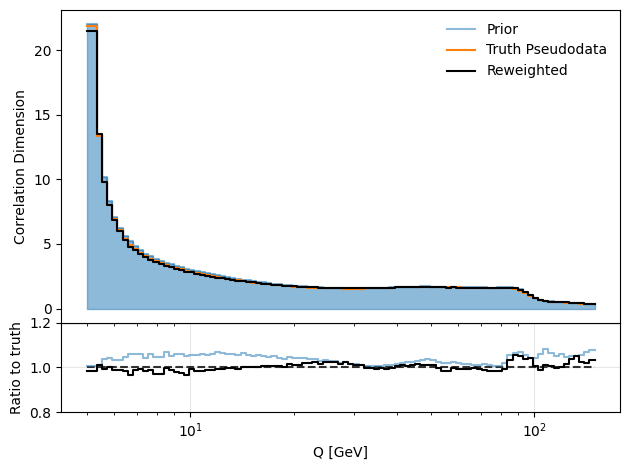

In [11]:
# Plot!
comp = vis.compare_to_pd(
    all_hists,
    prior_key="prior",
    measured_key="nominal",
    truth_key="truthpd",
    prior_label="Prior",
    measured_label="Reweighted",
    truth_label="Truth Pseudodata",
    linear_yscale=True,
    ylabel="Correlation Dimension",
    xlabel="Q [GeV]",
)

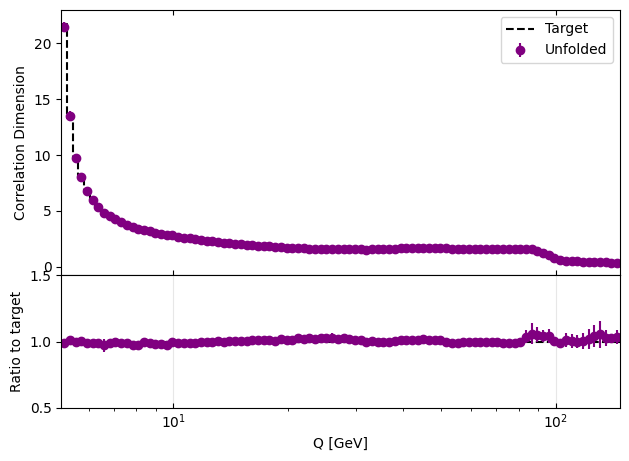

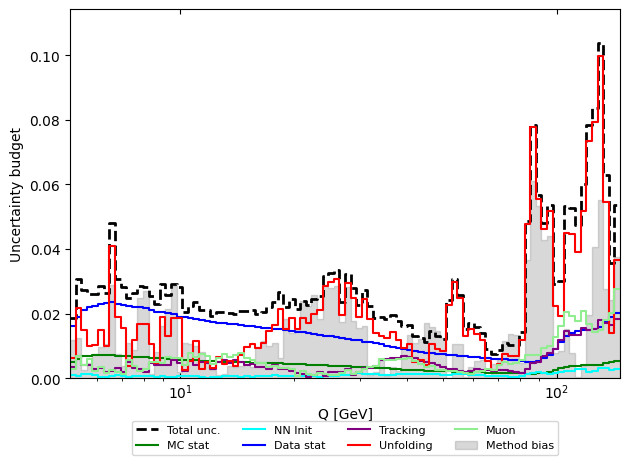

In [12]:
xsec, budget = vis.plot_uncertainties(
    all_hists,
    measured_key="nominal",
    target_key="truthpd",
    figsize=(6.4, 4.8),
    color="purple",
    linear_yscale=True,
)
xsec.show()
budget.show()